# Walkthrough: does the model recover a truth it was handed?

This notebook reruns Layer P, the synthetic advertiser with disclosed truth, on the tiny profile (a shorter window and a small sampling budget, so it finishes in a few minutes). The numbers here are for illustration; the reported figures come from `python -m ambo.run layer_p` on the full profile and live under `reports/layer_p`.

In [1]:
import json
from pathlib import Path

from IPython.display import Image, display
import pandas as pd

from ambo.run import run_layer_p

OUT = Path('../reports/layer_p_tiny')
DATA = Path('../data/synthetic_tiny')
CONFIG = Path('../src/ambo/configs/tiny.yaml')

## 1. Generate the data, fit, evaluate

One call regenerates the data, fits the model twice (full window, then the holdout window), and writes every table and chart.

In [2]:
numbers = run_layer_p(CONFIG, OUT, DATA)
print(json.dumps({k: numbers[k] for k in ('weeks', 'parameters_covered', 'parameters_total', 'diagnostics_pass', 'elapsed_seconds')}, indent=2))

findfont: Failed to find font weight heavy for Liberation Mono, now using 700.


{
  "weeks": 104,
  "parameters_covered": 26,
  "parameters_total": 28,
  "diagnostics_pass": false,
  "elapsed_seconds": 33.0
}


## 2. The truth the model never sees

Every parameter of the data-generating process is written to `truth.json`. The model gets the weekly spend and revenue only.

In [3]:
truth = json.loads((DATA / 'truth.json').read_text())
pd.DataFrame(truth['channel_truth']).T[['decay', 'half_saturation', 'slope', 'effect', 'roas', 'contribution_share_of_revenue']]

,decay,half_saturation,slope,effect,roas,contribution_share_of_revenue
Paid Search,0.15,5000.0,0.9,25000.0,2.031737,0.119856
Paid Social,0.3,5000.0,1.0,15000.0,1.562279,0.071381
Print,0.5,9000.0,1.2,12000.0,1.287041,0.024065
Radio,0.4,10000.0,1.1,12000.0,0.940307,0.022689
TV,0.6,40000.0,1.4,40000.0,1.022598,0.098485


## 3. Sampler health

R-hat, effective sample size and divergences are checked against fixed thresholds on every fit. A failed gate is written down, never hidden.

In [4]:
diag = json.loads((OUT / 'diagnostics.json').read_text())
{k: diag[k] for k in ('max_rhat', 'min_ess_bulk', 'min_ess_tail', 'divergences', 'pass_all', 'attempts')}

{'max_rhat': 1.072326139274555,
 'min_ess_bulk': 32.64434046557725,
 'min_ess_tail': 64.45776113069854,
 'divergences': 0,
 'pass_all': False,
 'attempts': [{'divergences': 0,
   'draws': 100,
   'elapsed_seconds': 18.4,
   'max_rhat': 1.072326139274555,
   'min_ess': 32.64434046557725,
   'pass_all': False,
   'target_accept': 0.9}]}

## 4. Parameter recovery

Each line is a 90 percent posterior interval, the dot its median, the orange cross the true value. Offline channels with flighted spend recover tightly; always-on channels with steadier spend carry wider intervals, which is the honest answer when the data moves little.

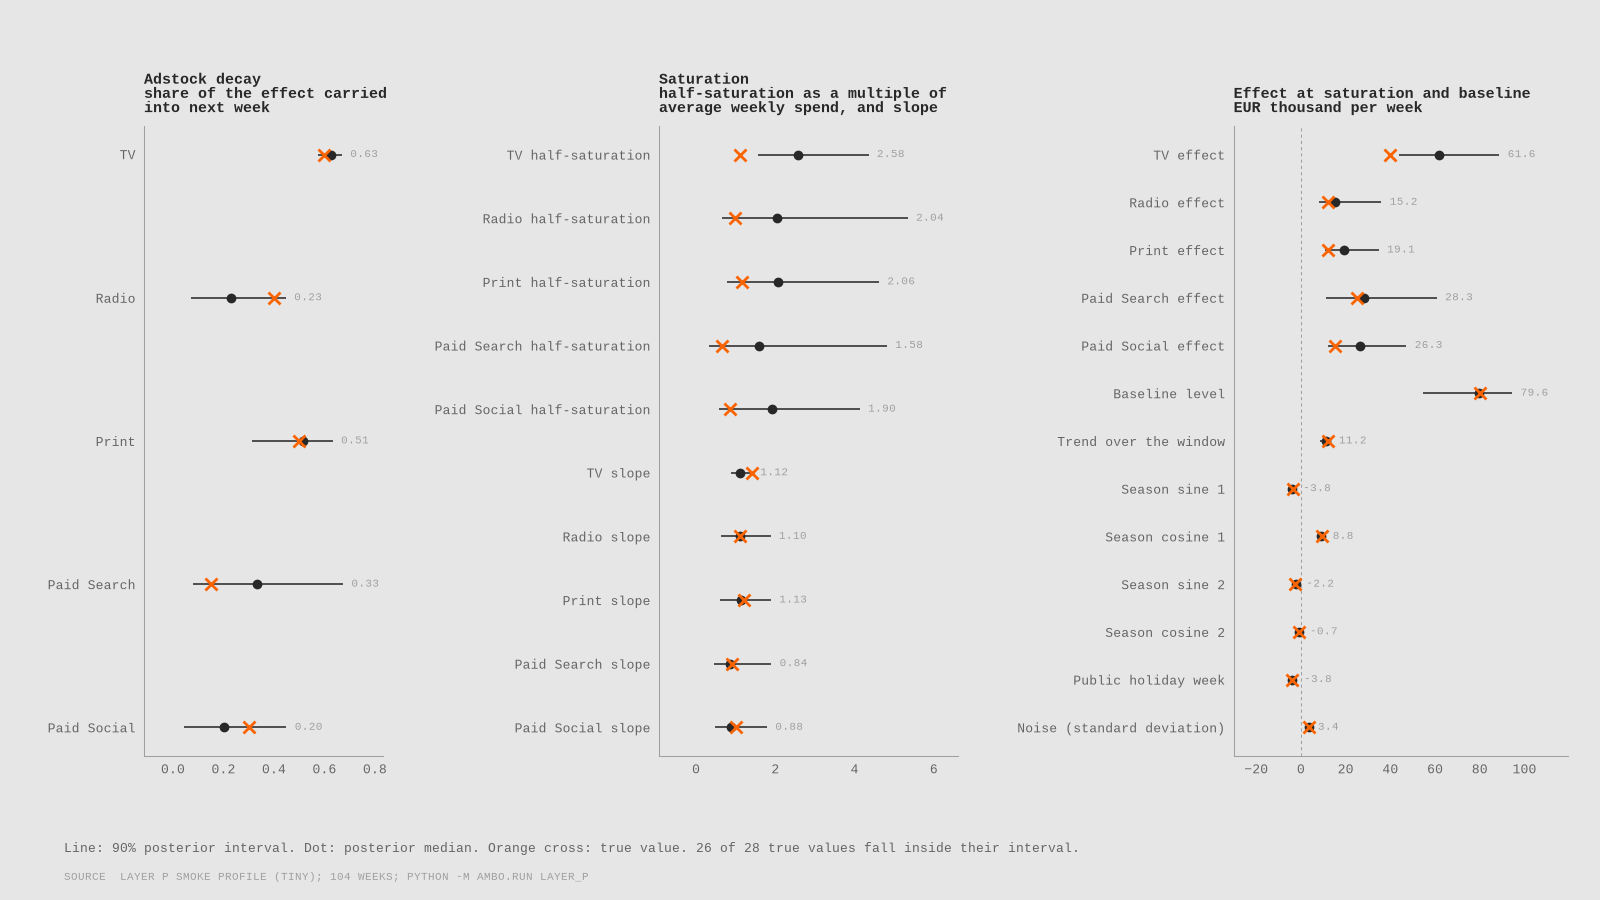

In [5]:
display(Image(filename=str(OUT / 'parameter_recovery.png'), width=1000))

In [6]:
rec = pd.read_csv(OUT / 'parameter_recovery.csv')
rec[['family', 'parameter', 'true', 'median', 'lo', 'hi', 'covered']]

,family,parameter,true,median,lo,hi,covered
0,Adstock decay,TV,0.600000,0.626402,0.575046,0.669262,True
1,Adstock decay,Radio,0.400000,0.228318,0.069875,0.447260,True
2,Adstock decay,Print,0.500000,0.513761,0.312184,0.632797,True
3,Adstock decay,Paid Search,0.150000,0.332551,0.078709,0.673568,True
4,Adstock decay,Paid Social,0.300000,0.202835,0.042760,0.449401,True
5,Saturation,TV half-saturation,1.116776,2.581823,1.559937,4.351168,False
6,Saturation,Radio half-saturation,0.990525,2.041005,0.642504,5.340732,True
7,Saturation,Print half-saturation,1.150449,2.058202,0.791943,4.614473,True
8,Saturation,Paid Search half-saturation,0.658388,1.578438,0.317963,4.815225,True
9,Saturation,Paid Social half-saturation,0.850059,1.904185,0.585682,4.130740,True


## 4b. Response curves against the truth

The orange line is the true response curve of the generator, the black line the posterior median and the band its 90 percent interval. This is the test a budget decision depends on: the curve at observed spend, not the individual parameters behind it.

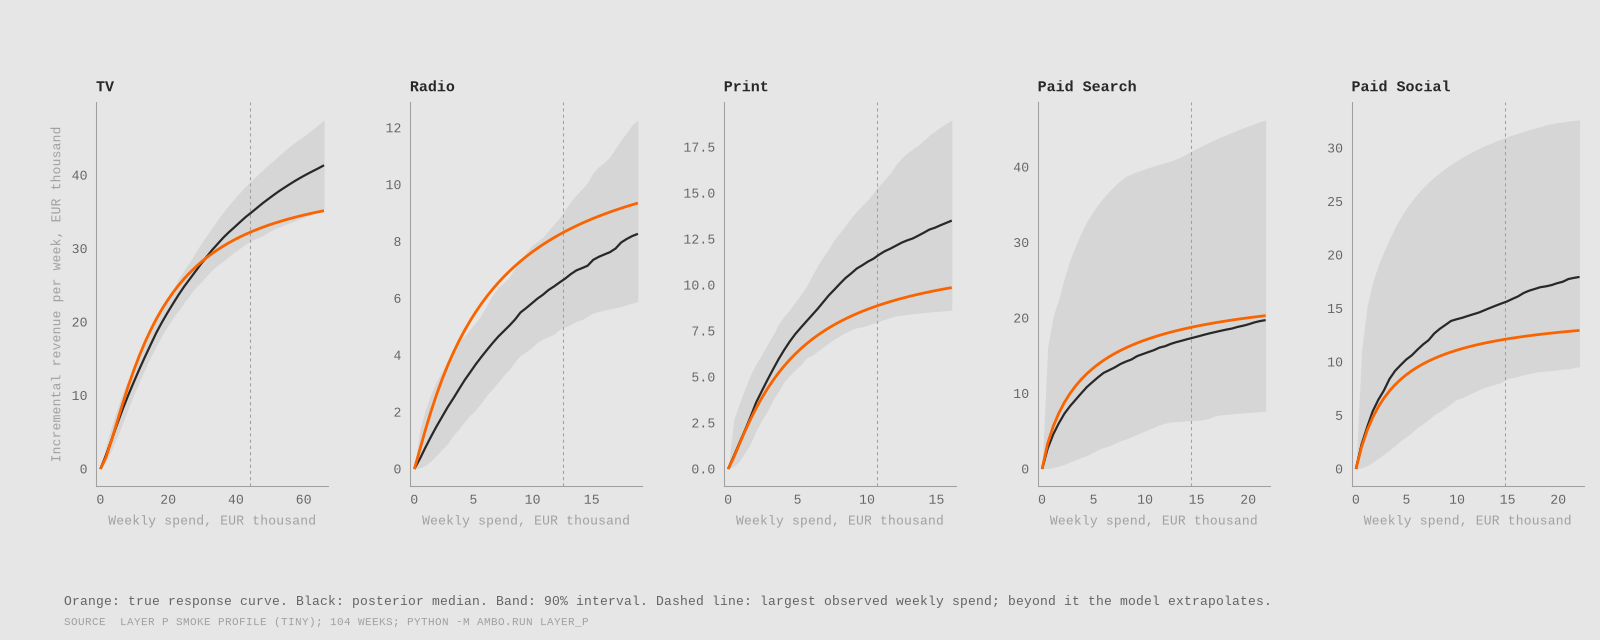

In [7]:
display(Image(filename=str(OUT / 'response_curve_recovery.png'), width=1000))

In [8]:
pd.read_csv(OUT / 'response_curve_metrics.csv')

,channel,curve_coverage_observed_range,curve_mae_pct_of_true_max,observed_max_spend,current_spend
0,TV,0.851852,3.603091,43991.0,12398.326923
1,Radio,0.629630,18.771504,12598.0,3106.355769
2,Print,1.000000,13.856785,10731.0,2407.086538
3,Paid Search,1.000000,8.376464,14459.0,7594.307692
4,Paid Social,1.000000,16.158300,14735.0,5881.942308


## 5. Contribution recovery

The share of revenue each channel drives is what a marketer acts on. It is recovered more tightly than the individual curve parameters, because half-saturation, slope and effect size trade off against each other while their product at observed spend does not.

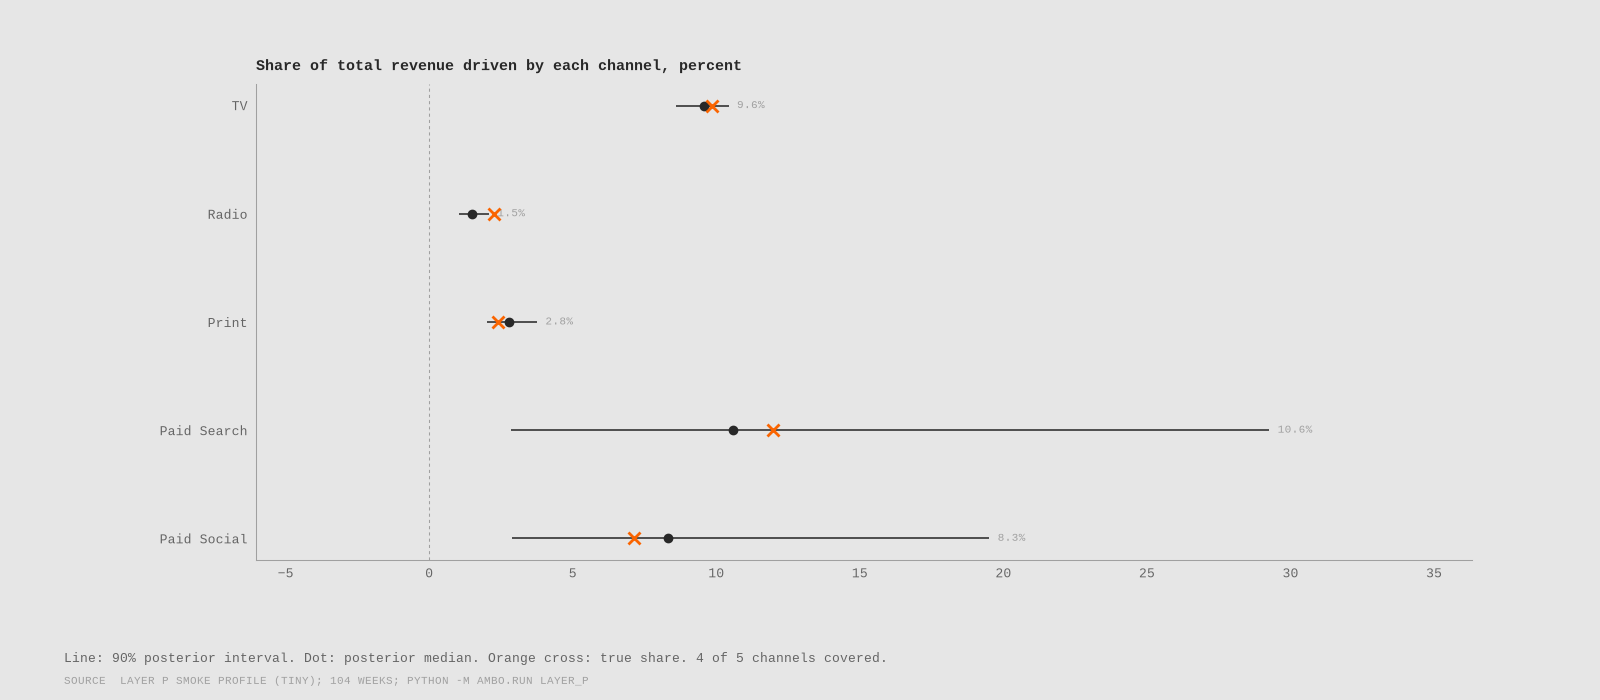

In [9]:
display(Image(filename=str(OUT / 'contribution_recovery.png'), width=1000))

## 6. Platform claims against incremental truth

The simulated platform report credits the online channels with their own effect inflated plus a slice of baseline demand, and credits offline media with nothing. Search ends up overstated and the upper funnel understated, which is the pattern practitioners see in last-touch dashboards.

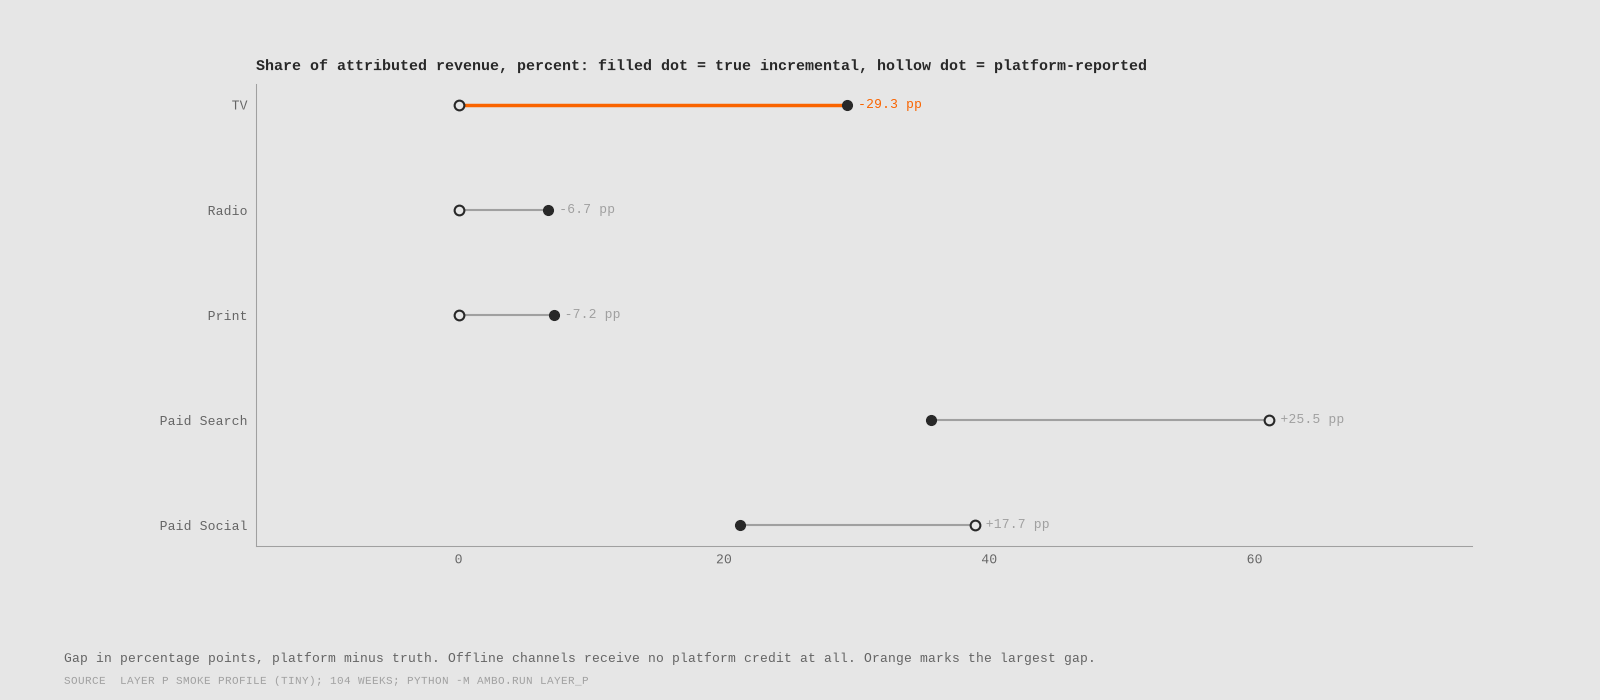

In [10]:
display(Image(filename=str(OUT / 'attribution_gap.png'), width=1000))

In [11]:
pd.read_csv(OUT / 'attribution_gap.csv')[['channel', 'platform_share', 'true_share', 'gap_pp', 'estimated_share_median']]

,channel,platform_share,true_share,gap_pp,estimated_share_median
0,TV,0.000000,0.292696,-29.269573,0.276115
1,Radio,0.000000,0.067433,-6.743253,0.043556
2,Print,0.000000,0.071521,-7.152080,0.081202
3,Paid Search,0.611054,0.356208,25.484608,0.310433
4,Paid Social,0.388946,0.212143,17.680300,0.237609


## 7. Holdout forecast

The model is refit on the first part of the window and forecasts the rest with the actual spend. Two baselines set the bar: last year's revenue for the same week, and a ridge regression on raw spend with month dummies. The MMM is not always the most accurate point forecaster; its value is calibrated uncertainty and a decomposition the baselines cannot give.

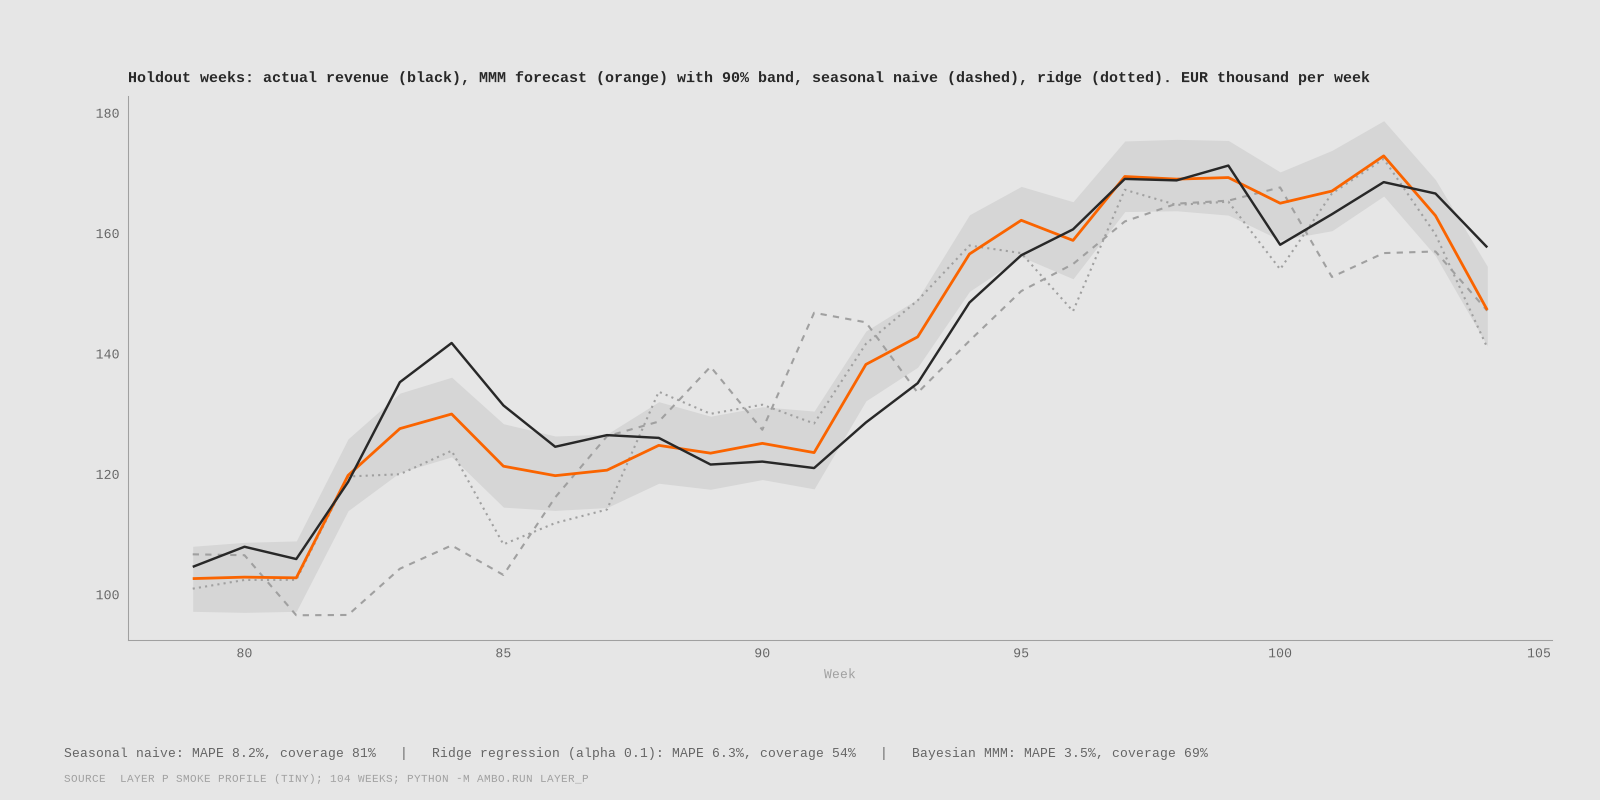

In [12]:
display(Image(filename=str(OUT / 'holdout.png'), width=1000))

In [13]:
pd.read_csv(OUT / 'holdout_metrics.csv')

,model,mape,coverage_90,interval_width_mean,n_test,train_weeks
0,Seasonal naive,0.082422,0.807692,41244.389247,26,78
1,Ridge regression (alpha 0.1),0.063419,0.538462,15775.122870,26,78
2,Bayesian MMM,0.034930,0.692308,12329.029764,26,78


## What to take away

A model that cannot recover parameters it was handed cannot be trusted on real data. This one recovers the observable quantities (contribution shares, ROAS, the direction of the attribution gap) on the default seed; the full profile results in `reports/layer_p` are the ones cited in the README.